## LEVEL 1

### Task 1: Data Cleaning and Preprocessing

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv('2) Stock Prices Data Set.csv')

In [49]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [50]:
df.tail()

,symbol,date,open,high,low,close,volume
497467,XYL,2017-12-29,68.53,68.80,67.92,68.20,1046677
497468,YUM,2017-12-29,82.64,82.71,81.59,81.61,1347613
497469,ZBH,2017-12-29,121.75,121.95,120.62,120.67,1023624
497470,ZION,2017-12-29,51.28,51.55,50.81,50.83,1261916
497471,ZTS,2017-12-29,72.55,72.76,72.04,72.04,1704122


In [51]:
# Checking for null values
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [52]:
# There are 27 null values in this dataset

In [53]:
#Using forward fill to fill these null values
df.ffill(inplace=True)

In [54]:
#Checking the presence of null values after prforming Forward Fill
df.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [55]:
#All null values have successfully been foward filled with the last previous known figure

In [56]:
#Checking the current data type of the date column
df['date'].dtype

dtype('O')

In [57]:
# This shows that the date column is currently stored as Object and should be converted to datetime

In [58]:
#Converting date column to datetime
df['date'] = pd.to_datetime(df['date'])

In [59]:
#Checking if the conversion worked
df['date'].dtype

dtype('<M8[ns]')

In [60]:
df['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 497472 entries, 0 to 497471
Series name: date
Non-Null Count   Dtype         
--------------   -----         
497472 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 3.8 MB


In [61]:
#The date column has successfully been converted from object to datetime

In [62]:
#Checking the number of duplicated rows
df.duplicated().sum()

np.int64(0)

In [63]:
# This indicated that there are no duplicates in the dataset.
# This means every row is unique

In [64]:
#Checking for consistency in the symbol column - if all values are capitalized
df['symbol'].str.isupper().all()

np.True_

In [29]:
# Since it returned true, it means all values are capitalized

In [65]:
df.to_csv('cleaned_stock_prices.csv', index=False)

### Task 2: Exploratory Data Analysis (EDA)

In [30]:
df1 = pd.read_csv('1) iris.csv')

In [31]:
df1.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [32]:
df1.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [34]:
# Summary Statistics
# The median is shown at 50%
df1.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [36]:
# The summary statistics does not include the Mode 
# Checking the mode
df1.mode().iloc[0]

sepal_length       5.0
sepal_width        3.0
petal_length       1.5
petal_width        0.2
species         setosa
Name: 0, dtype: object

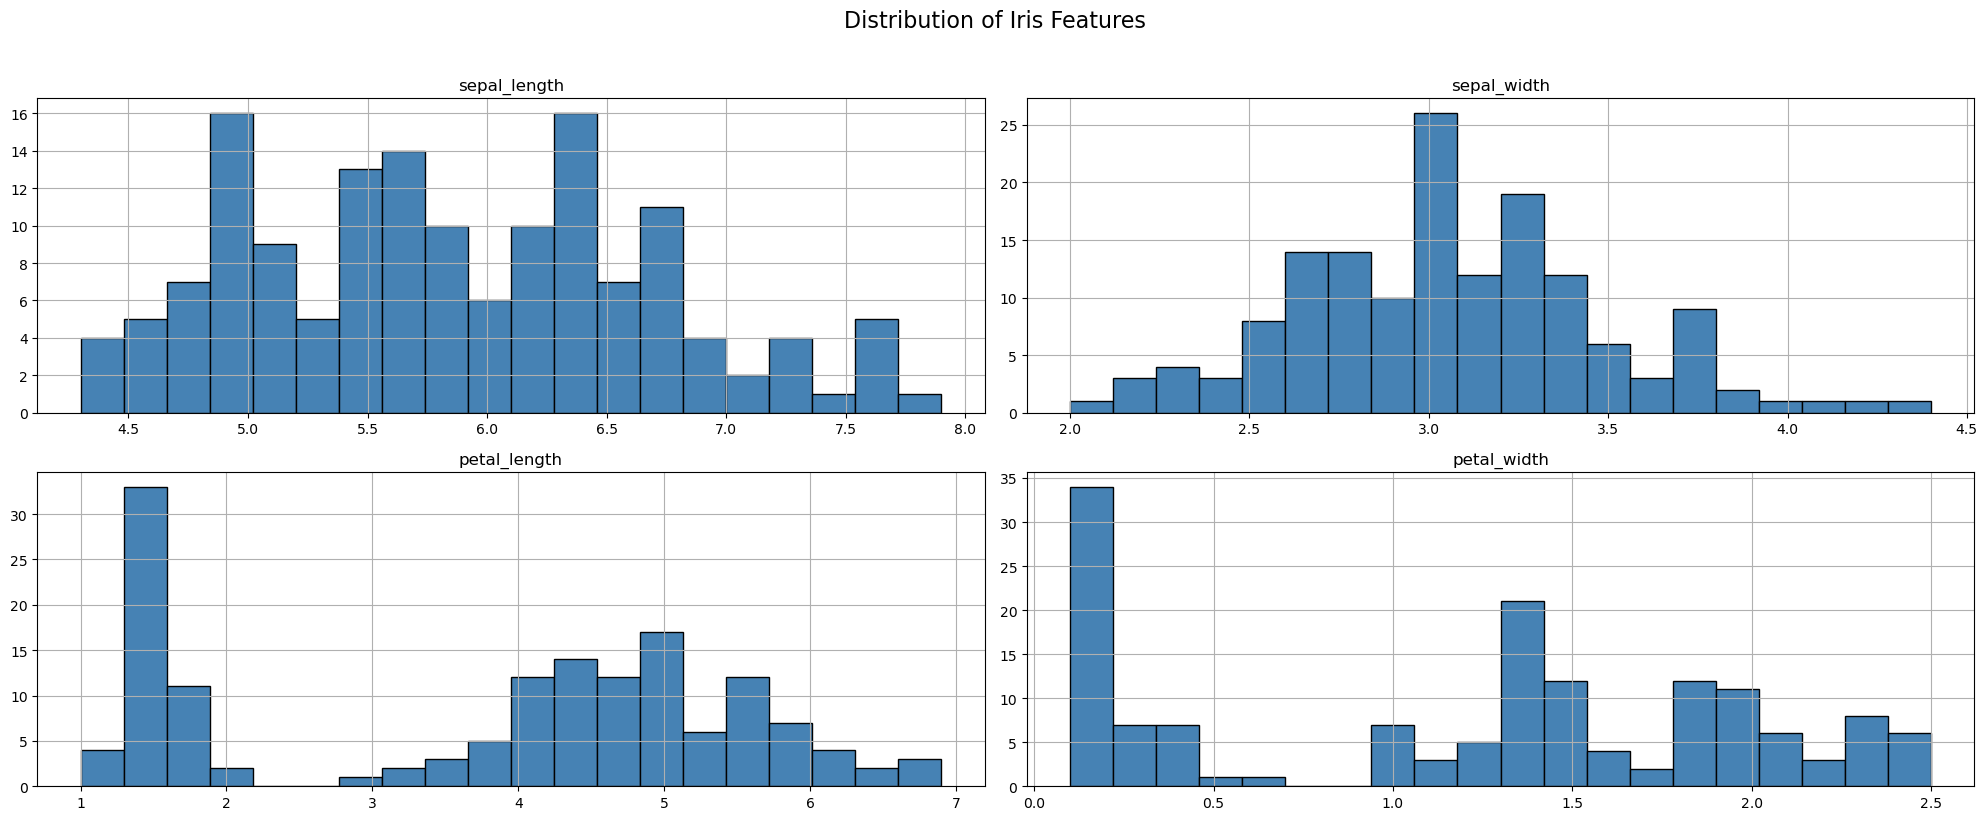

In [42]:
#Histogram
df1.hist(figsize=(20, 8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Iris Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

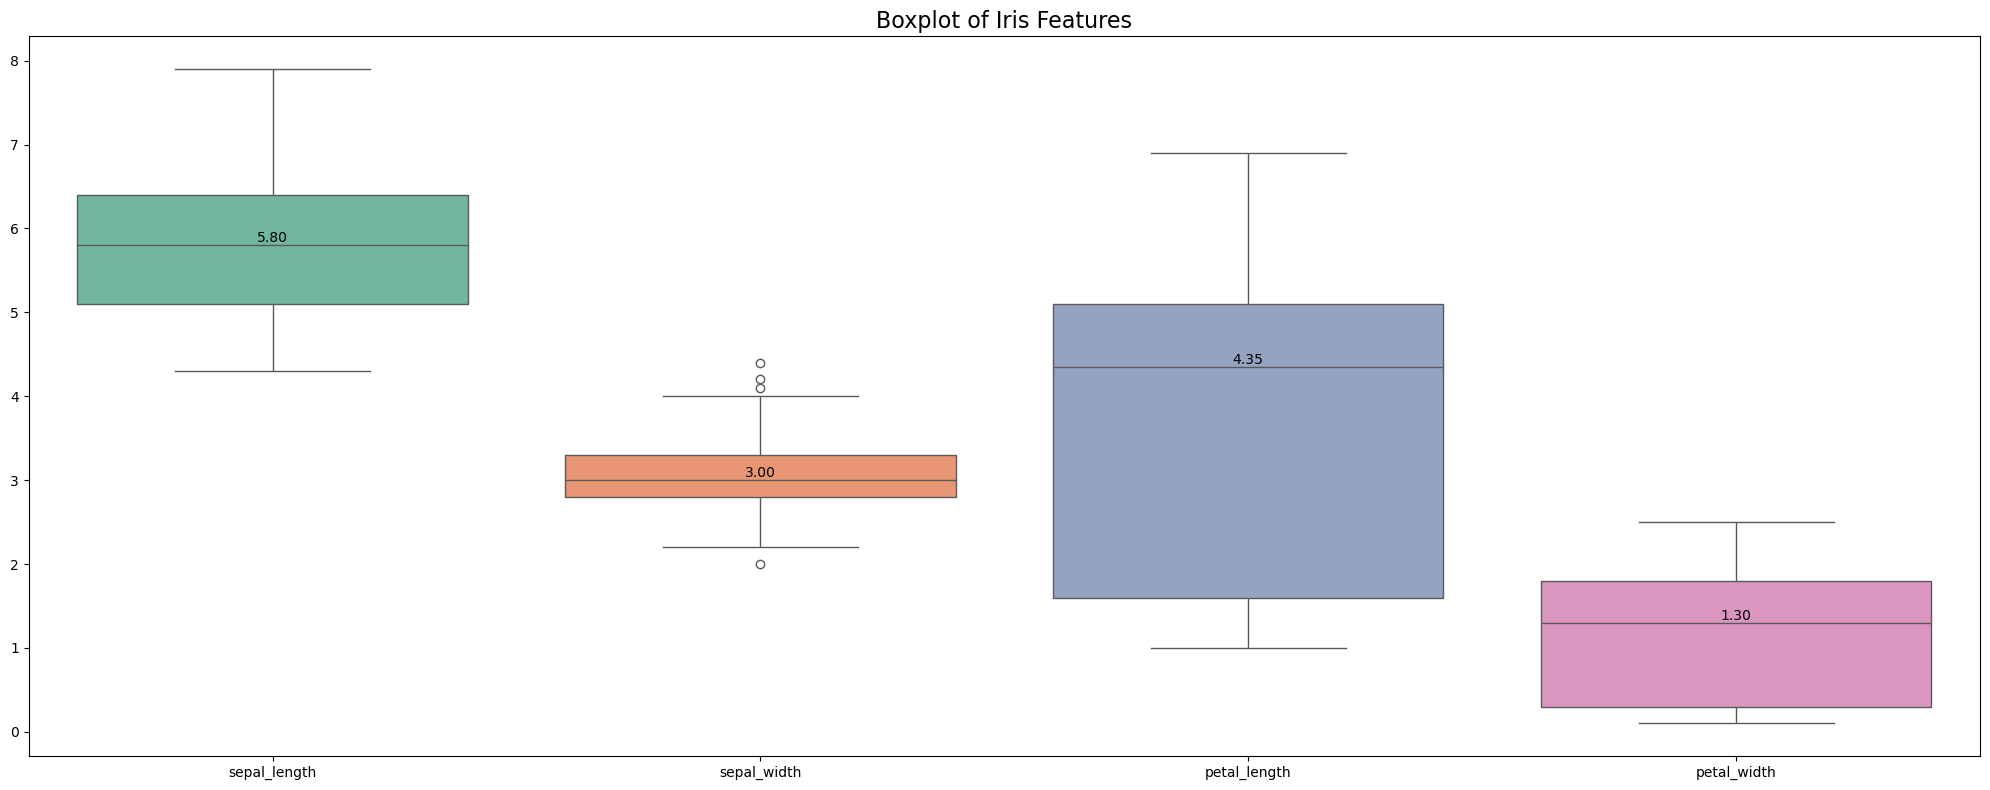

In [44]:
#Boxplot
plt.figure(figsize=(20, 8))
sns.boxplot(data=df1, palette='Set2')
plt.title('Boxplot of Iris Features', fontsize=16)
for i, feature in enumerate(df1.select_dtypes(include='number').columns):
    median = df1[feature].median()
    plt.text(i, median, f'{median:.2f}', ha='center', va='bottom', fontsize=10, color='black')
plt.tight_layout()
plt.show()

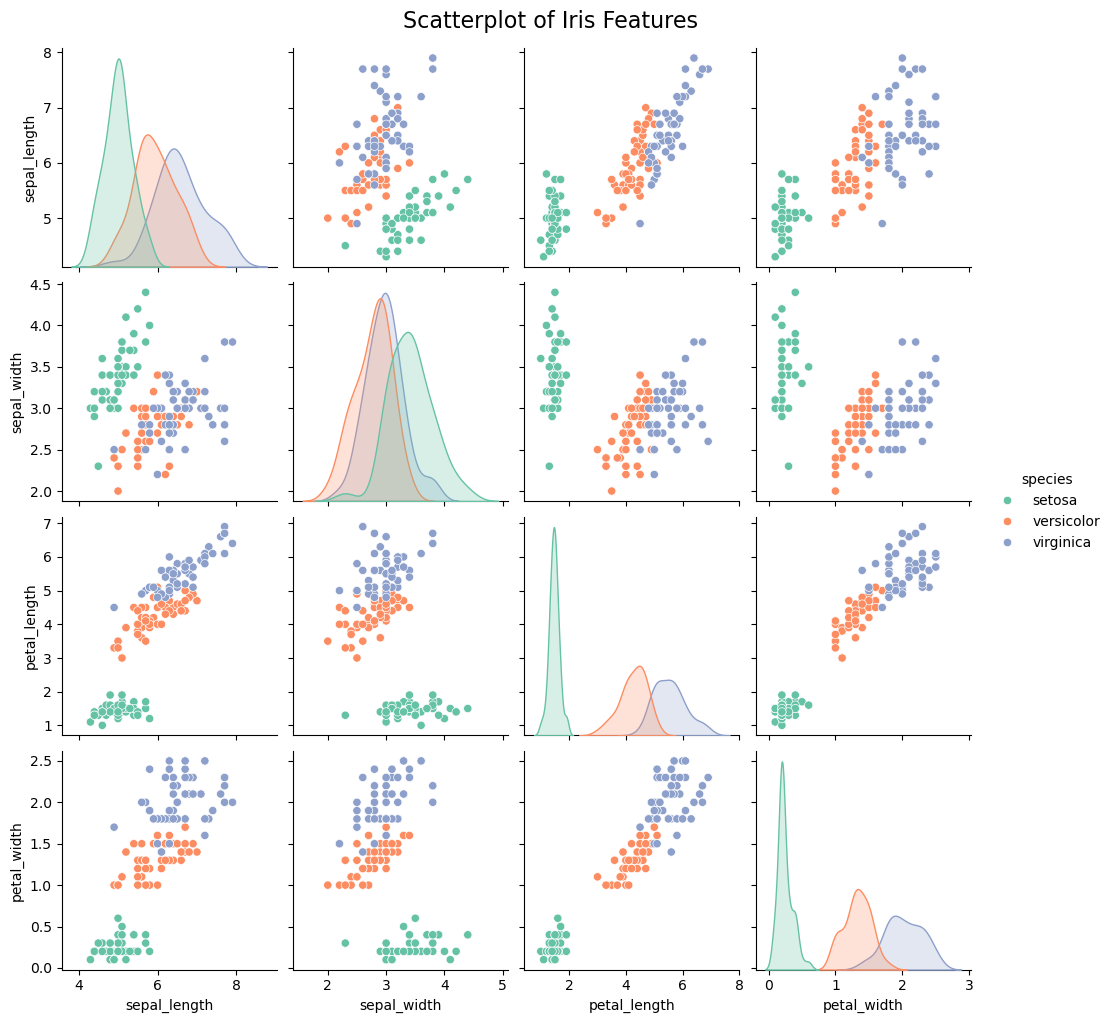

In [45]:
#Scatterplot
sns.pairplot(df1, hue='species', palette='Set2')
plt.suptitle('Scatterplot of Iris Features', y=1.02, fontsize=16)
plt.show()

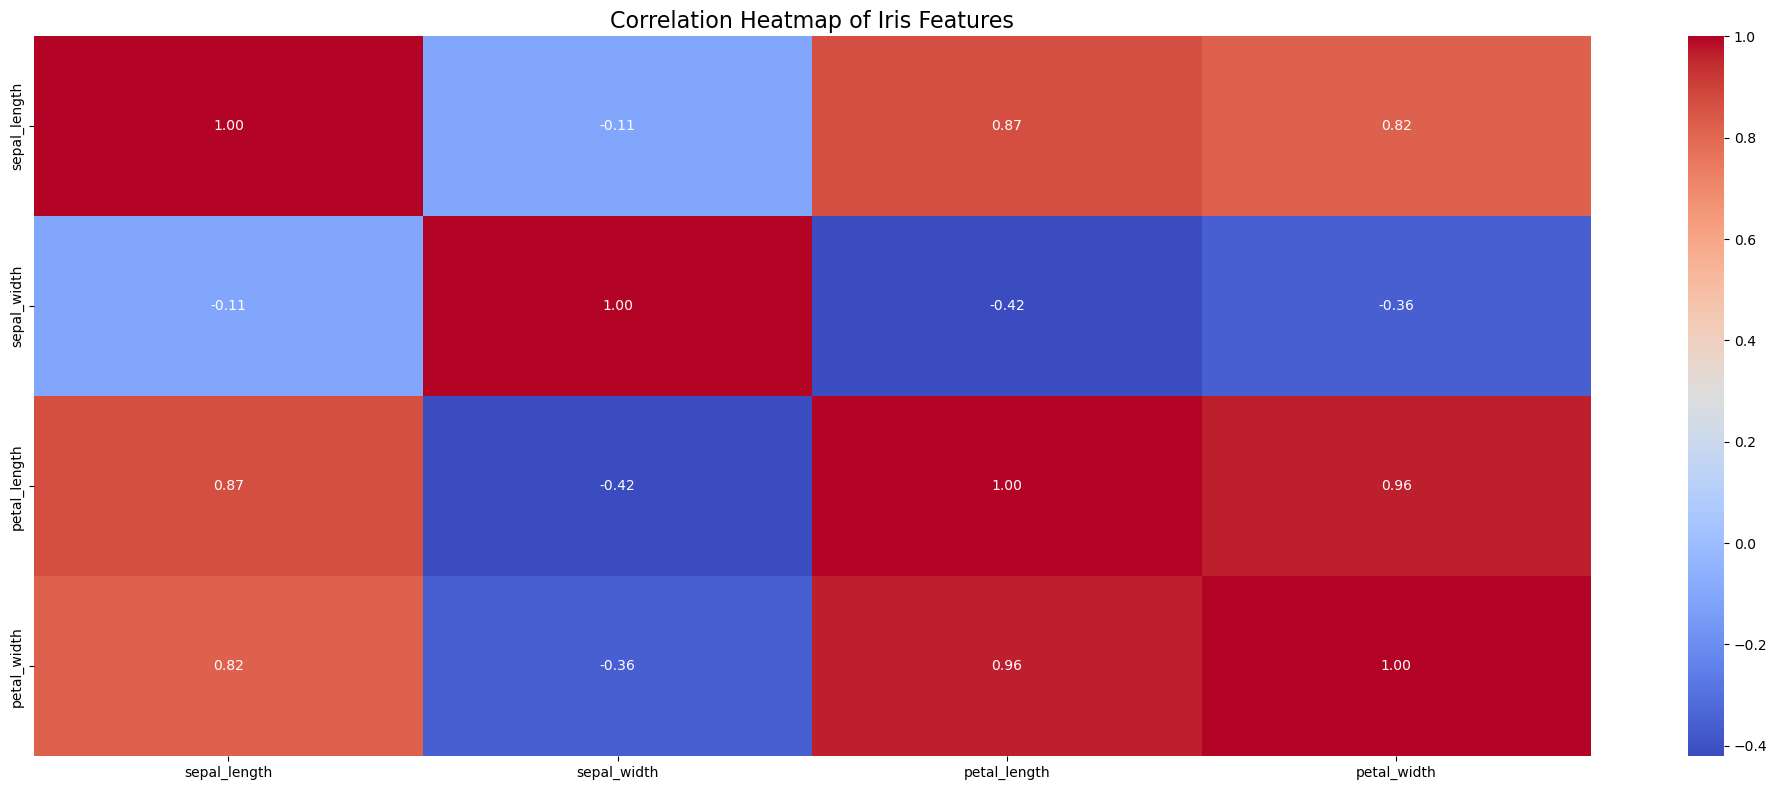

In [46]:
#Correlation
plt.figure(figsize=(20, 8))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Iris Features', fontsize=16)
plt.tight_layout()
plt.show()